-- Prototype Project based on synthetic datasets.

Task:
DXB wants you to forecast 2026-2030 annual pax so they can plan capacity accordingly 

Datasets contains covid shock effect (external variable) also gdp, and fuel price as external variable

dataset is excel file may contain duplicate and missing values

Model - exogenous (external variable)
x - features (such as variables)
y - target (what we are predicting)

In [176]:
print("Hello SARIMAX")

Hello SARIMAX


In [177]:
%pip install openpyxl

Note: you may need to restart the kernel to use updated packages.


In [178]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


%pip install openpyxl

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_acf

from statsmodels.tsa.stattools import adfuller

#model accuracy
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, root_mean_squared_error

Note: you may need to restart the kernel to use updated packages.


steps
load dataset

shape -- observation, columns
info - observations, column dtypes
missing value - 
duplicates

date range
describe

will see how data looks over time

split train, test

build model
ARIMA
SARIMA
SARIMAX (with exog[])

compare all model accuracy

In [179]:
df = pd.read_excel("data/traffic data/dxb_pax_20_25_covid_shock.xlsx")

df.head()

,date,pax,gdp_growth_pct,avg_fuel_price_usd_l,covid_effect
0,2001-12-31,13500000.0,3.1,0.62,0.0
1,2002-12-31,16000000.0,5.0,0.60,0.0
2,2003-12-31,18060000.0,5.2,0.72,0.0
3,2004-12-31,21700000.0,5.4,0.85,0.0
4,31/05/2005,23610000.0,4.8,1.15,0.0


In [180]:
df.tail(7)

,date,pax,gdp_growth_pct,avg_fuel_price_usd_l,covid_effect
19,2020-12-31,18200000.0,-6.1,1.35,-0.95
20,2021-12-31,29110000.0,3.5,1.55,-0.70
21,2022-12-31,66070000.0,7.0,2.35,-0.45
22,2023-12-31,86990000.0,3.4,2.10,-0.15
23,2024-12-31,92300000.0,3.6,2.05,0.00
24,2025-12-31,95200000.0,4.0,2.05,0.00
25,2019-12-31,86400000.0,1.2,NaN,0.00


In [181]:
df.shape

(26, 5)

In [182]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 26 entries, 0 to 25
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   date                  26 non-null     str    
 1   pax                   26 non-null     float64
 2   gdp_growth_pct        25 non-null     float64
 3   avg_fuel_price_usd_l  24 non-null     float64
 4   covid_effect          26 non-null     float64
dtypes: float64(4), str(1)
memory usage: 1.1 KB


In [183]:
df[df.duplicated()]

,date,pax,gdp_growth_pct,avg_fuel_price_usd_l,covid_effect
25,2019-12-31,86400000.0,1.2,NaN,0.0


In [184]:
# lets drop duplicates
df.drop_duplicates(inplace=True)

df.duplicated().sum()

np.int64(0)

In [185]:
df.isnull().sum()

date                    0
pax                     0
gdp_growth_pct          1
avg_fuel_price_usd_l    1
covid_effect            0
dtype: int64

In [186]:
df[df["gdp_growth_pct"].isnull()]

,date,pax,gdp_growth_pct,avg_fuel_price_usd_l,covid_effect
12,2013-12-31,66430000.0,NaN,3.15,0.0


In [187]:
df[df["avg_fuel_price_usd_l"].isnull()]

,date,pax,gdp_growth_pct,avg_fuel_price_usd_l,covid_effect
18,2019-12-31,86400000.0,1.2,NaN,0.0


In [188]:
# lets fillna with avg for gdp and fuel price

avg_fuel = df["avg_fuel_price_usd_l"].mean()
avg_gdp = df["gdp_growth_pct"].mean()

df["avg_fuel_price_usd_l"] = df["avg_fuel_price_usd_l"].fillna(avg_fuel)

df["gdp_growth_pct"] = df["gdp_growth_pct"].fillna(avg_gdp)

df.isnull().sum()

date                    0
pax                     0
gdp_growth_pct          0
avg_fuel_price_usd_l    0
covid_effect            0
dtype: int64

In [189]:
df.describe()

,pax,gdp_growth_pct,avg_fuel_price_usd_l,covid_effect
count,2.500000e+01,25.000000,25.00000,25.000000
mean,5.361640e+07,3.612500,1.93875,-0.090000
std,2.851538e+07,2.535467,0.78846,0.242813
min,1.350000e+07,-6.100000,0.60000,-0.950000
25%,2.879000e+07,3.100000,1.42000,0.000000
50%,5.098000e+07,3.900000,1.95000,0.000000
75%,8.365000e+07,5.000000,2.55000,0.000000
max,9.520000e+07,7.000000,3.15000,0.000000


In [190]:
# lets see the date field

df["date"].head(25)

0      2001-12-31
1      2002-12-31
2      2003-12-31
3      2004-12-31
4      31/05/2005
5      2006-12-31
6      2007-12-31
7      2008-12-31
8      2009-12-31
9      2010/12/31
10     2011-12-31
11     2012-12-31
12     2013-12-31
13     2014-12-31
14     2015-12-31
15    31-Dec-2016
16     2017-12-31
17     2018-12-31
18     2019-12-31
19     2020-12-31
20     2021-12-31
21     2022-12-31
22     2023-12-31
23     2024-12-31
24     2025-12-31
Name: date, dtype: str

In [191]:
df["new_date"] = pd.to_datetime(df["date"], dayfirst=True, errors="coerce")

/var/folders/r6/w18clwvn0bv96s8gbr9087c40000gn/T/ipykernel_81363/3090702140.py:1: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df["new_date"] = pd.to_datetime(df["date"], dayfirst=True, errors="coerce")


In [192]:
df[df["new_date"].isnull()]

,date,pax,gdp_growth_pct,avg_fuel_price_usd_l,covid_effect,new_date
4,31/05/2005,23610000.0,4.8,1.15,0.0,NaT
9,2010/12/31,47180000.0,1.0,1.95,0.0,NaT
15,31-Dec-2016,83650000.0,3.1,2.35,0.0,NaT


In [193]:
df["date"] = df["date"].replace({
        "31/05/2005" : "2005-12-31",
        "2010/12/31" :"2010-12-31",
         "31-Dec-2016" : "2016-12-31"
    })

df["date"].isnull().sum()

np.int64(0)

In [194]:
df["date"].head(25)

0     2001-12-31
1     2002-12-31
2     2003-12-31
3     2004-12-31
4     2005-12-31
5     2006-12-31
6     2007-12-31
7     2008-12-31
8     2009-12-31
9     2010-12-31
10    2011-12-31
11    2012-12-31
12    2013-12-31
13    2014-12-31
14    2015-12-31
15    2016-12-31
16    2017-12-31
17    2018-12-31
18    2019-12-31
19    2020-12-31
20    2021-12-31
21    2022-12-31
22    2023-12-31
23    2024-12-31
24    2025-12-31
Name: date, dtype: str

In [195]:
# now lets convert to datetime

df["date"] = pd.to_datetime(df["date"])
df.dtypes

date                    datetime64[us]
pax                            float64
gdp_growth_pct                 float64
avg_fuel_price_usd_l           float64
covid_effect                   float64
new_date                datetime64[us]
dtype: object

In [196]:
# now lets set datetime as index

df = df.set_index("date")

df.sort_index(inplace=True)

df.head()

,pax,gdp_growth_pct,avg_fuel_price_usd_l,covid_effect,new_date
date,,,,,
2001-12-31,13500000.0,3.1,0.62,0.0,2001-12-31
2002-12-31,16000000.0,5.0,0.60,0.0,2002-12-31
2003-12-31,18060000.0,5.2,0.72,0.0,2003-12-31
2004-12-31,21700000.0,5.4,0.85,0.0,2004-12-31
2005-12-31,23610000.0,4.8,1.15,0.0,NaT


In [197]:
df.index

DatetimeIndex(['2001-12-31', '2002-12-31', '2003-12-31', '2004-12-31',
               '2005-12-31', '2006-12-31', '2007-12-31', '2008-12-31',
               '2009-12-31', '2010-12-31', '2011-12-31', '2012-12-31',
               '2013-12-31', '2014-12-31', '2015-12-31', '2016-12-31',
               '2017-12-31', '2018-12-31', '2019-12-31', '2020-12-31',
               '2021-12-31', '2022-12-31', '2023-12-31', '2024-12-31',
               '2025-12-31'],
              dtype='datetime64[us]', name='date', freq=None)

In [198]:
df.head()

,pax,gdp_growth_pct,avg_fuel_price_usd_l,covid_effect,new_date
date,,,,,
2001-12-31,13500000.0,3.1,0.62,0.0,2001-12-31
2002-12-31,16000000.0,5.0,0.60,0.0,2002-12-31
2003-12-31,18060000.0,5.2,0.72,0.0,2003-12-31
2004-12-31,21700000.0,5.4,0.85,0.0,2004-12-31
2005-12-31,23610000.0,4.8,1.15,0.0,NaT


In [199]:
# dropping unwanted col new_date

df = df.drop(columns={"new_date"})

df.head()

,pax,gdp_growth_pct,avg_fuel_price_usd_l,covid_effect
date,,,,
2001-12-31,13500000.0,3.1,0.62,0.0
2002-12-31,16000000.0,5.0,0.60,0.0
2003-12-31,18060000.0,5.2,0.72,0.0
2004-12-31,21700000.0,5.4,0.85,0.0
2005-12-31,23610000.0,4.8,1.15,0.0


In [200]:
# lets find min and max date

df.index.min()

Timestamp('2001-12-31 00:00:00')

In [201]:
df.index.max()

Timestamp('2025-12-31 00:00:00')

<Axes: xlabel='date'>

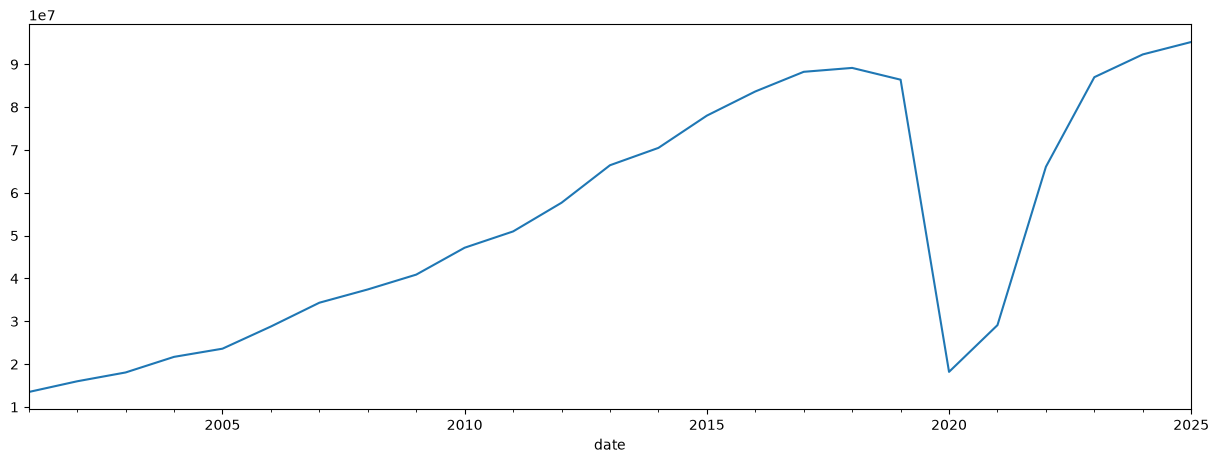

In [202]:
# lets see how data looks like over time

df["pax"].plot(figsize=(15, 5))

In [203]:
df.index

DatetimeIndex(['2001-12-31', '2002-12-31', '2003-12-31', '2004-12-31',
               '2005-12-31', '2006-12-31', '2007-12-31', '2008-12-31',
               '2009-12-31', '2010-12-31', '2011-12-31', '2012-12-31',
               '2013-12-31', '2014-12-31', '2015-12-31', '2016-12-31',
               '2017-12-31', '2018-12-31', '2019-12-31', '2020-12-31',
               '2021-12-31', '2022-12-31', '2023-12-31', '2024-12-31',
               '2025-12-31'],
              dtype='datetime64[us]', name='date', freq=None)

In [204]:
df.tail(6)

,pax,gdp_growth_pct,avg_fuel_price_usd_l,covid_effect
date,,,,
2020-12-31,18200000.0,-6.1,1.35,-0.95
2021-12-31,29110000.0,3.5,1.55,-0.70
2022-12-31,66070000.0,7.0,2.35,-0.45
2023-12-31,86990000.0,3.4,2.10,-0.15
2024-12-31,92300000.0,3.6,2.05,0.00
2025-12-31,95200000.0,4.0,2.05,0.00


In [205]:
# our data has uptrends our with masiv covid shock than recovery

# lets analyze covid shock data

df[df["covid_effect"] < 0]


,pax,gdp_growth_pct,avg_fuel_price_usd_l,covid_effect
date,,,,
2020-12-31,18200000.0,-6.1,1.35,-0.95
2021-12-31,29110000.0,3.5,1.55,-0.70
2022-12-31,66070000.0,7.0,2.35,-0.45
2023-12-31,86990000.0,3.4,2.10,-0.15


In [ ]:
# first we will use ARIMA (Base model)
# as our data has masive covid shock we will use SARIMA(exogenous variable model)

# first plan to use 2001-2020 for model train and test on 2021-2025

# lets create train test (but we will)
# df_train - :2020
# df_test - 2021: 


In [ ]:
# train size 20 obs (2001-2020)

df_train = df.loc[:"2020", "pax"]
df_train.head()

date
2001-12-31    13500000.0
2002-12-31    16000000.0
2003-12-31    18060000.0
2004-12-31    21700000.0
2005-12-31    23610000.0
Name: pax, dtype: float64

In [246]:
df_train.shape

(20,)

In [250]:
# test size obs 5 (2021-2025)

df_test = df.loc["2021":, "pax"]
df_test.tail(5)

date
2021-12-31    29110000.0
2022-12-31    66070000.0
2023-12-31    86990000.0
2024-12-31    92300000.0
2025-12-31    95200000.0
Name: pax, dtype: float64

In [235]:
# lets first do adf test to see if our data is stationary

from statsmodels.tsa.stattools import adfuller

# adfuller(df["pax"].diff().diff().dropna())


adfuller(df["pax"].diff().dropna())

/var/folders/r6/w18clwvn0bv96s8gbr9087c40000gn/T/ipykernel_81363/753141033.py:8: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adfuller(df["pax"].diff().dropna())


(-2.0549684712512413,
 0.26300302545312654,
 7,
 16,
 {'1%': np.float64(-3.9240193847656246),
  '5%': np.float64(-3.0684982031250003),
  '10%': np.float64(-2.67389265625)},
 np.float64(513.7097239336501))

In [231]:
# lets perform plot_pacf, plot_acf to see how current value depends on past and decide p,q

from statsmodels.graphics.tsaplots import plot_pacf, plot_acf

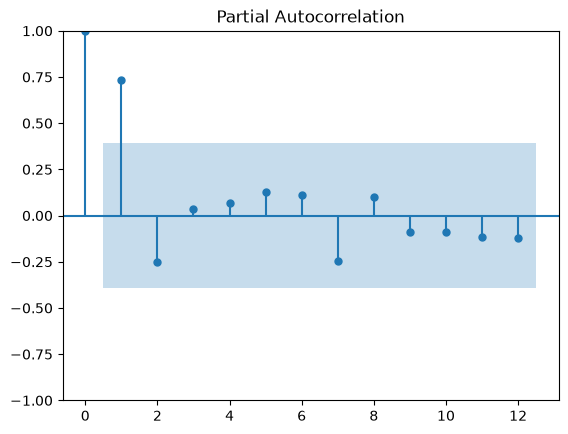

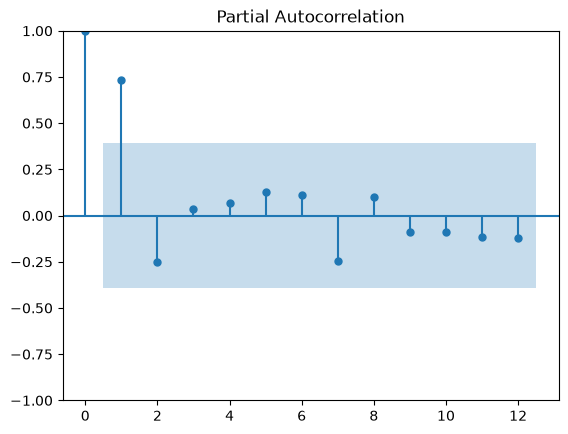

In [232]:
plot_pacf(df["pax"], 
          lags=12)

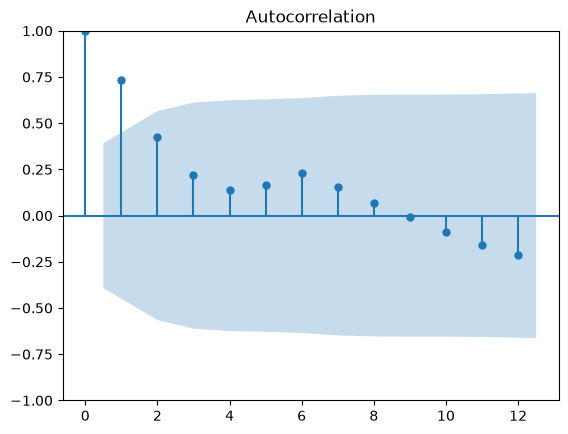

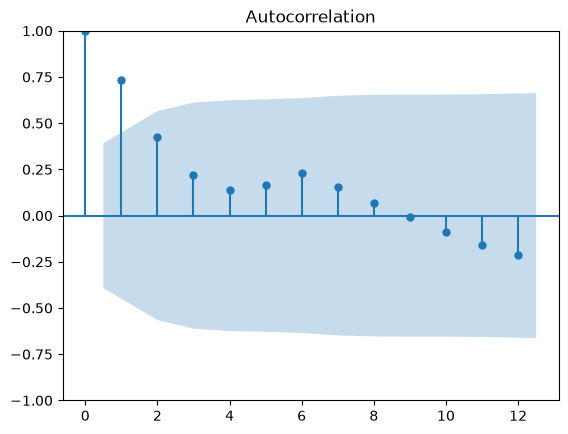

In [233]:
plot_acf(df["pax"], 
          lags=12)

We can see strongly related at lag1 and gradually less depends after lag2 so we can choose base p=1, q=1

In [ ]:
# diff() first and second level doesnt help as data has massive covid shock
# so we will use base ARIMA with candidate (p,d,q order=(1, 1, 1))

In [252]:
# define model
model_arima_101 = ARIMA(
                        df_train,
                        order=(1, 0, 1)
                        )


# fitting/training model
model_arima_train_101 = model_arima_101.fit()

print(model_arima_train_101.summary())

                               SARIMAX Results                                
Dep. Variable:                    pax   No. Observations:                   20
Model:                 ARIMA(1, 0, 1)   Log Likelihood                -359.823
Date:                Thu, 03 Sep 2026   AIC                            727.645
Time:                        22:03:24   BIC                            731.628
Sample:                    12-31-2001   HQIC                           728.423
                         - 12-31-2020                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       4.854e+07   1.37e-08   3.55e+15      0.000    4.85e+07    4.85e+07
ar.L1          0.7115      0.384      1.854      0.064      -0.041       1.463
ma.L1          0.4877      2.084      0.234      0.8

/Users/zara/Developer/Workspace/DS/Forecasting Models/venv_fm2/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency YE-DEC will be used.
  self._init_dates(dates, freq)
/Users/zara/Developer/Workspace/DS/Forecasting Models/venv_fm2/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency YE-DEC will be used.
  self._init_dates(dates, freq)
/Users/zara/Developer/Workspace/DS/Forecasting Models/venv_fm2/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency YE-DEC will be used.
  self._init_dates(dates, freq)


In [253]:
# lets forecast with model

model_arima_101_forecast = model_arima_train_101.forecast(len(df_test))


In [254]:
model_arima_101_forecast

2021-12-31   -2.273863e+06
2022-12-31    1.238661e+07
2023-12-31    2.281709e+07
2024-12-31    3.023807e+07
2025-12-31    3.551786e+07
Freq: YE-DEC, Name: predicted_mean, dtype: float64

In [262]:
# lets build a func to check MAE, MAPE, RMSE



def model_accuracy(model_name, actual, forecasted_value):
    
    #MAE
    mae = mean_absolute_error(actual, forecasted_value)
    
    # mape
    mape = mean_absolute_percentage_error(actual, forecasted_value)
    
    # rmse
    rmse = root_mean_squared_error(actual, forecasted_value)
    
    # create dict to store results of all models
    
    result = {
        "MAE": mae,
        "MAPE" : mape,
        "RMSE" : rmse
    }
    
    
    print("Model :", model_name, "\n", result)


# lets test with our first model data arima_101

model_accuracy("model_arima_101", df_test, model_arima_101_forecast)
    
    

Model : model_arima_101 
 {'MAE': 54196846.3827196, 'MAPE': 0.7855293972125156, 'RMSE': 55495326.75553711}


In [ ]:
pd.DataFrame({
    "Actual" : df_test/1_000_000,
    "Predicted" : model_arima_101_forecast/1_000_000,
    "Error"  :  df_test-model_arima_101_forecast/1_000_000
})

,Actual,Predicted,Model Bias
2021-12-31,29.11,-2.273863,2.911000e+07
2022-12-31,66.07,12.386610,6.606999e+07
2023-12-31,86.99,22.817093,8.698998e+07
2024-12-31,92.30,30.238065,9.229997e+07
2025-12-31,95.20,35.517862,9.519996e+07


In [268]:
# lets try with candidate 1,1,1

# define model
model_arima_111 = ARIMA(
                        df_train,
                        order=(1, 1, 1)                            
                        )

# train
model_arima_111_train = model_arima_111.fit()


# printing model summary
print(model_arima_111_train.summary())


# forecasting with model
model_arima_111_forecast = model_arima_111_train.forecast(len(df_test))

                               SARIMAX Results                                
Dep. Variable:                    pax   No. Observations:                   20
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -341.484
Date:                Thu, 03 Sep 2026   AIC                            688.967
Time:                        22:29:54   BIC                            691.801
Sample:                    12-31-2001   HQIC                           689.447
                         - 12-31-2020                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9979      3.071      0.325      0.745      -5.021       7.017
ma.L1          0.2504      4.928      0.051      0.959      -9.408       9.909
sigma2      2.845e+14   1.72e-13   1.65e+27      0.0

/Users/zara/Developer/Workspace/DS/Forecasting Models/venv_fm2/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency YE-DEC will be used.
  self._init_dates(dates, freq)
/Users/zara/Developer/Workspace/DS/Forecasting Models/venv_fm2/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency YE-DEC will be used.
  self._init_dates(dates, freq)
/Users/zara/Developer/Workspace/DS/Forecasting Models/venv_fm2/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency YE-DEC will be used.
  self._init_dates(dates, freq)
/Users/zara/Developer/Workspace/DS/Forecasting Models/venv_fm2/lib/python3.11/site-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros

In [269]:
# lets validate model accurry

model_accuracy("model_arima_111", df_test, model_arima_111_forecast)

Model : model_arima_111 
 {'MAE': 307856493.68581295, 'MAPE': 3.978806522214024, 'RMSE': 338754530.2524658}


In [ ]:
# lets see model bias

pd.DataFrame(
   { "actual" : df_test/1_000_000,
    "predicted" : model_arima_111_forecast/1_000_000,
    "model bias" : (df_test-model_arima_111_forecast)/1_000_000}
)

,actual,predicted,model bias
2021-12-31,29.11,-66.073026,95.183026
2022-12-31,66.07,-150.171635,216.241635
2023-12-31,86.99,-234.096189,321.086189
2024-12-31,92.30,-317.847048,410.147048
2025-12-31,95.20,-401.424571,496.624571


In [310]:
# lets define exog -- external variable as x and y - target and define train test accordingly

# variable exog
x = df[['avg_fuel_price_usd_l', 'covid_effect', 'gdp_growth_pct']]
# target
y = df["pax"]


# train x, test x (2001-2020)
x_train = x.loc[:"2020"]


x_test = x.loc["2021":]


# lets define target y_train, y_test
y_train = y.loc[:"2020"]

y_test = y.loc["2021":]

In [311]:
# lets verify
print("x_train",x_train.shape)
print("y_train",y_train.shape)

# lets verify
print("x_test",x_test.shape)
print("y_test",x_test.shape)

x_train (20, 3)
y_train (20,)
x_test (5, 3)
y_test (5, 3)


In [312]:
# now lets build SARIMAX(with exogenous variable)

# define the model (as we can use exog in SARIMA so we use SARIMA model but define only ARIMA order=(1,1,1))
model_sarima_exog_111 = SARIMAX(
                                y_train,
                                exog=x_train,
                                order=(1, 1, 1)                                    
                                )



# model training
model_sarima_exog_111_train = model_sarima_exog_111.fit()


# model summary
print(model_sarima_exog_111_train.summary())


model_sarima_exog_111_forecast = model_sarima_exog_111_train.forecast(len(y_test), exog=x_test)


                               SARIMAX Results                                
Dep. Variable:                    pax   No. Observations:                   20
Model:               SARIMAX(1, 1, 1)   Log Likelihood                -308.890
Date:                Thu, 03 Sep 2026   AIC                            629.779
Time:                        23:15:35   BIC                            635.446
Sample:                    12-31-2001   HQIC                           630.738
                         - 12-31-2020                                         
Covariance Type:                  opg                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
avg_fuel_price_usd_l  4.407e+06   1.87e+04    235.158      0.000    4.37e+06    4.44e+06
covid_effect          7.399e+07   2.28e+04   3247.907      0.000    7.39e+07     7.4e+07
gdp_growth_p

/Users/zara/Developer/Workspace/DS/Forecasting Models/venv_fm2/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency YE-DEC will be used.
  self._init_dates(dates, freq)
/Users/zara/Developer/Workspace/DS/Forecasting Models/venv_fm2/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency YE-DEC will be used.
  self._init_dates(dates, freq)


In [314]:
model_sarima_exog_111_forecast/1_000_000

2021-12-31    32.122959
2022-12-31    52.503100
2023-12-31    76.424535
2024-12-31    87.616574
2025-12-31    87.738778
Freq: YE-DEC, Name: predicted_mean, dtype: float64

In [315]:
y_test/1_000_000

date
2021-12-31    29.11
2022-12-31    66.07
2023-12-31    86.99
2024-12-31    92.30
2025-12-31    95.20
Name: pax, dtype: float64

In [316]:
# lets check model accuracy

model_accuracy("model_sarima_exog_111", y_test, model_sarima_exog_111_forecast)


Model : model_sarima_exog_111 
 {'MAE': 7857994.44062261, 'MAPE': 0.11188309396171033, 'RMSE': 8744964.975577222}


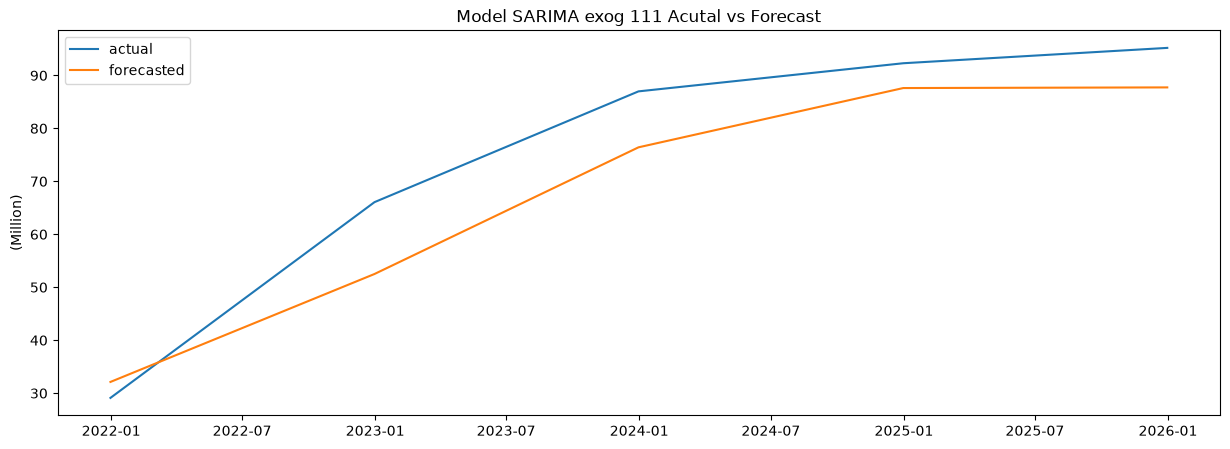

In [317]:
# ploting actual vs forecast in plot

plt.figure(figsize=(15, 5))

# actual
plt.plot(
    y_test.index, 
    y_test/1_000_000, 
    label="actual"
)

# forecast
plt.plot(
    y_test.index,
    model_sarima_exog_111_forecast/1_000_000,
    label="forecasted"
)

plt.legend()
plt.ylabel("(Million)")
plt.title("Model SARIMA exog 111 Acutal vs Forecast")
plt.show()

In [318]:
# comparing yearly error

comparison = pd.DataFrame({
                            "actual" : y_test,
                            "predicted" : model_sarima_exog_111_forecast
                        })

# adding error
# ape (anual % error)
comparison["error"] = comparison["actual"] - comparison["predicted"]
comparison["ape"] = (abs(comparison["error"])/comparison["actual"]) * 100

comparison

,actual,predicted,error,ape
2021-12-31,29110000.0,3.212296e+07,-3.012959e+06,10.350255
2022-12-31,66070000.0,5.250310e+07,1.356690e+07,20.534131
2023-12-31,86990000.0,7.642454e+07,1.056546e+07,12.145608
2024-12-31,92300000.0,8.761657e+07,4.683426e+06,5.074135
2025-12-31,95200000.0,8.773878e+07,7.461222e+06,7.837418


In [ ]:
# The model performed well in 2022–2025 but struggled during the immediate recovery period.

Investigation of exogenous coefficients

fuel coefficient     +3.931M
COVID coefficient   +69.35M

In [319]:
model_sarima_exog_111_train.params

avg_fuel_price_usd_l    4.406972e+06
covid_effect            7.398893e+07
gdp_growth_pct         -6.416562e+05
ar.L1                   8.564318e-01
ma.L1                  -5.431132e-01
sigma2                  7.757553e+12
dtype: float64

In [300]:
model_sarima_exog_111_train.pvalues

avg_fuel_price_usd_l    0.000000e+00
covid_effect            0.000000e+00
ar.L1                   1.927799e-15
ma.L1                   2.876754e-02
sigma2                  0.000000e+00
dtype: float64

In [320]:
# resid diagnosis
model_sarima_exog_111_resid = model_sarima_exog_111_train.resid
model_sarima_exog_111_resid

date
2001-12-31    1.275681e+07
2002-12-31   -2.054653e+06
2003-12-31   -2.635009e+06
2004-12-31    3.734656e+05
2005-12-31   -2.332178e+06
2006-12-31    3.450339e+06
2007-12-31    3.048387e+06
2008-12-31   -2.249814e+06
2009-12-31    1.516790e+06
2010-12-31    1.315784e+06
2011-12-31   -8.097020e+05
2012-12-31    4.975602e+06
2013-12-31    4.823319e+06
2014-12-31    1.179467e+06
2015-12-31    5.417150e+06
2016-12-31    1.053756e+06
2017-12-31   -2.195141e+06
2018-12-31   -3.521072e+06
2019-12-31   -4.046810e+05
2020-12-31   -1.296657e+06
dtype: float64

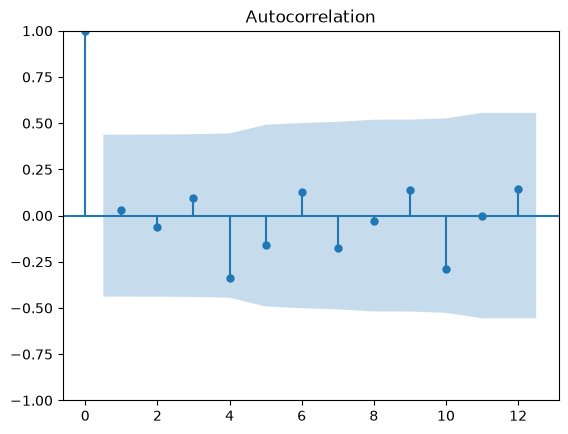

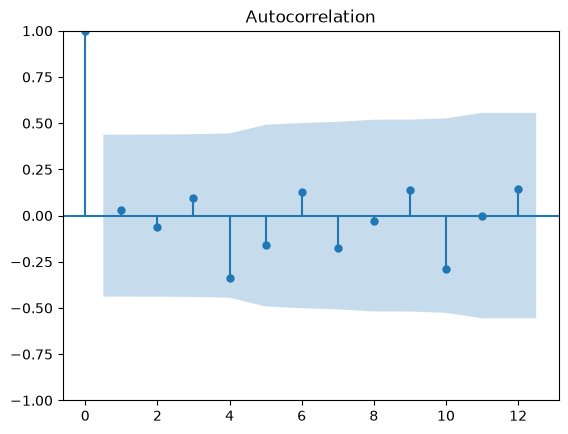

In [307]:
plot_acf(model_sarima_exog_111_resid, lags=12)

so resids seems fine no no relevant correlate with past lags

cross validation with other version of SARIMA [without fuel]

In [308]:
x_train.columns

Index(['avg_fuel_price_usd_l', 'covid_effect'], dtype='str')

In [ ]:
# now lets test with without gdp, and one without fuel price and as well covid & fuel

In [321]:
x_train

,avg_fuel_price_usd_l,covid_effect,gdp_growth_pct
date,,,
2001-12-31,0.62000,0.00,3.1000
2002-12-31,0.60000,0.00,5.0000
2003-12-31,0.72000,0.00,5.2000
2004-12-31,0.85000,0.00,5.4000
2005-12-31,1.15000,0.00,4.8000
2006-12-31,1.42000,0.00,6.2000
2007-12-31,1.55000,0.00,6.8000
2008-12-31,1.85000,0.00,5.1000
2009-12-31,1.72000,0.00,4.0000


In [322]:
x_train_fuel_ce = x_train[['avg_fuel_price_usd_l', 'covid_effect']] #only ce- covid effect and avg fuel

x_train_ce = x_train['covid_effect'] #only with covid effect


# lets create same for x test

x_test_fuel_ce = x_test[['avg_fuel_price_usd_l', 'covid_effect']]
x_test_ce = x_test['covid_effect']


print(
    "x_train_fuel_ce shape:", x_train_fuel_ce.shape, "\n",
    "x_train_ce shape:", x_train_ce.shape, "\n",
    "x_trax_test_fuel_ce  shape:", x_test_fuel_ce.shape, "\n",
    "x_test_ce  shape:", x_test_ce.shape, "\n",
    
      )

x_train_fuel_ce shape: (20, 2) 
 x_train_ce shape: (20,) 
 x_trax_test_fuel_ce  shape: (5, 2) 
 x_test_ce  shape: (5,) 



In [324]:
x_train_fuel_ce

,avg_fuel_price_usd_l,covid_effect
date,,
2001-12-31,0.62000,0.00
2002-12-31,0.60000,0.00
2003-12-31,0.72000,0.00
2004-12-31,0.85000,0.00
2005-12-31,1.15000,0.00
2006-12-31,1.42000,0.00
2007-12-31,1.55000,0.00
2008-12-31,1.85000,0.00
2009-12-31,1.72000,0.00


In [323]:
x_test_fuel_ce

,avg_fuel_price_usd_l,covid_effect
date,,
2021-12-31,1.55,-0.70
2022-12-31,2.35,-0.45
2023-12-31,2.10,-0.15
2024-12-31,2.05,0.00
2025-12-31,2.05,0.00


In [404]:
# lets define model SARIMA same candidate ( order=(1, 1, 1))

# define the model
model_sarima_111_fuel_ce = SARIMAX(
                                   y_train, #target train pax
                                   exog=x_train_fuel_ce, #exogenous variable could affecting pax
                                   order=(1, 1, 1)                                     
                                    )

# model traing
model_sarima_111_fuel_ce_train = model_sarima_111_fuel_ce.fit()



# print summary
print(model_sarima_111_fuel_ce_train.summary())


# forecasting for 2021-2025
model_sarima_111_fuel_ce_forecast = model_sarima_111_fuel_ce_train.forecast(len(y_test), exog=x_test_fuel_ce)



                               SARIMAX Results                                
Dep. Variable:                    pax   No. Observations:                   20
Model:               SARIMAX(1, 1, 1)   Log Likelihood                -308.921
Date:                Fri, 04 Sep 2026   AIC                            627.842
Time:                        21:12:05   BIC                            632.564
Sample:                    12-31-2001   HQIC                           628.641
                         - 12-31-2020                                         
Covariance Type:                  opg                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
avg_fuel_price_usd_l  3.931e+06   2.48e-09   1.58e+15      0.000    3.93e+06    3.93e+06
covid_effect          6.935e+07   1.67e-08   4.15e+15      0.000    6.94e+07    6.94e+07
ar.L1       

/Users/zara/Developer/Workspace/DS/Forecasting Models/venv_fm2/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency YE-DEC will be used.
  self._init_dates(dates, freq)
/Users/zara/Developer/Workspace/DS/Forecasting Models/venv_fm2/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency YE-DEC will be used.
  self._init_dates(dates, freq)


In [327]:
model_sarima_111_fuel_ce_forecast/1_000_000

2021-12-31    37.944109
2022-12-31    59.929078
2023-12-31    81.145652
2024-12-31    92.644248
2025-12-31    93.842612
Freq: YE-DEC, Name: predicted_mean, dtype: float64

In [ ]:
y_test/1_000_000

date
2021-12-31    29.11
2022-12-31    66.07
2023-12-31    86.99
2024-12-31    92.30
2025-12-31    95.20
Name: pax, dtype: float64

In [330]:
# let's check model accuracy 

model_accuracy("model_sarima_111_fuel_CovidShock", model_sarima_111_fuel_ce_forecast, y_test)

Model : model_sarima_111_fuel_CovidShock 
 {'MAE': 4504203.196764724, 'MAPE': 0.08509841584916941, 'RMSE': 5511258.039682916}


In [333]:
# lets see actual vs forecasted in df

comparison_2 = pd.DataFrame(
    {
        "Actual" : y_test/1_000_000,
        "Predicted" : model_sarima_111_fuel_ce_forecast/1_000_000
    }
)

comparison_2["Error"] = comparison_2["Actual"] - comparison_2["Predicted"]
comparison_2["Ape"] = abs(comparison_2["Error"]) / comparison_2["Actual"] * 100


comparison_2

,Actual,Predicted,Error,Ape
2021-12-31,29.11,37.944109,-8.834109,30.347335
2022-12-31,66.07,59.929078,6.140922,9.294570
2023-12-31,86.99,81.145652,5.844348,6.718414
2024-12-31,92.30,92.644248,-0.344248,0.372967
2025-12-31,95.20,93.842612,1.357388,1.425828


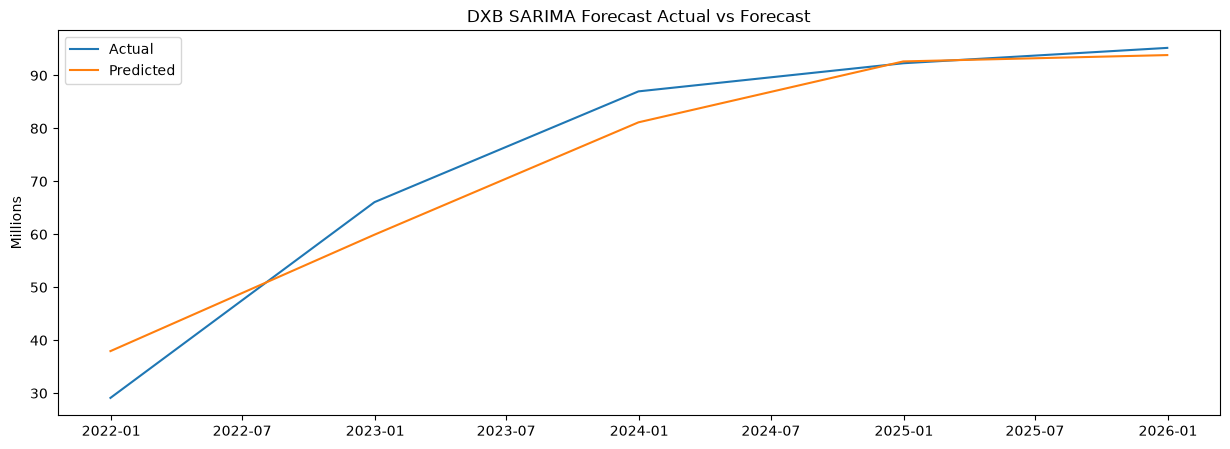

In [337]:
# lets plot actual vs predicted over time

plt.figure(figsize=(15, 5))

plt.plot(
    y_test.index,
    y_test/1_000_000,
    label="Actual"
)

plt.plot(
    y_test.index,
    model_sarima_111_fuel_ce_forecast/1_000_000,
    label="Predicted"
)

plt.ylabel("Millions")
plt.title("DXB SARIMA Forecast Actual vs Forecast")
plt.legend()
plt.show()

In [338]:
# lets check model resid

model_sarima_111_fuel_ce_train.resid

date
2001-12-31    1.106304e+07
2002-12-31   -1.910158e+06
2003-12-31   -1.996178e+06
2004-12-31    3.236964e+05
2005-12-31   -1.948826e+06
2006-12-31    2.083702e+06
2007-12-31    2.679784e+06
2008-12-31   -8.680051e+05
2009-12-31    1.578057e+06
2010-12-31    2.805525e+06
2011-12-31   -2.548408e+06
2012-12-31    3.494049e+06
2013-12-31    5.519199e+06
2014-12-31    5.860315e+05
2015-12-31    5.787979e+06
2016-12-31    1.703086e+06
2017-12-31   -1.740644e+06
2018-12-31   -3.903022e+06
2019-12-31   -1.643740e+06
2020-12-31   -2.295634e+06
dtype: float64

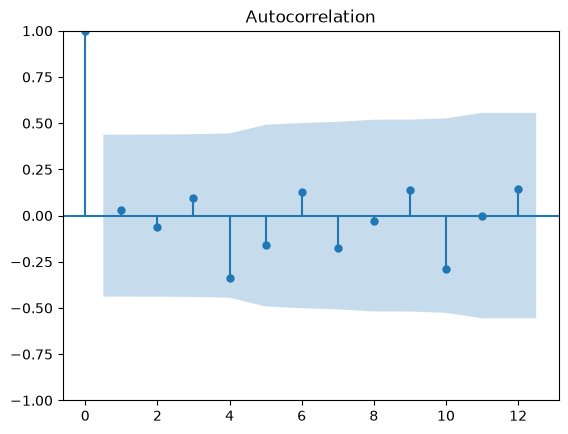

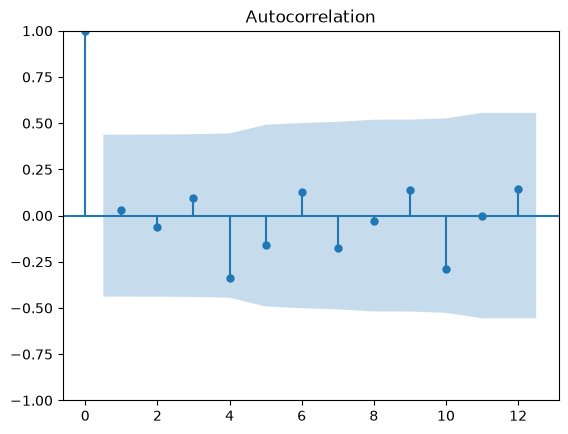

In [344]:
# lets see if there any correlation in residual with itself at lag

plot_acf(
model_sarima_111_fuel_ce_train.resid, lags=12)

<Axes: xlabel='date'>

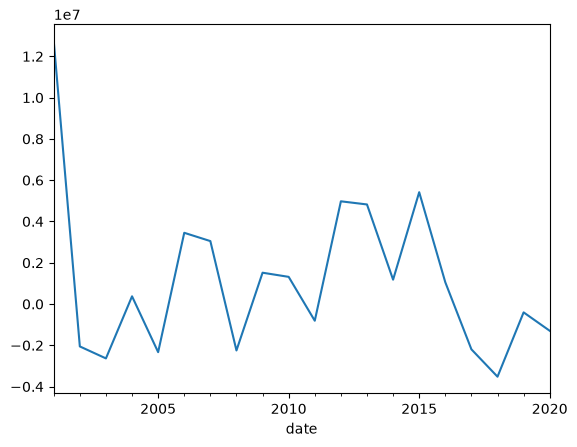

In [349]:
# no dependency on past lags

residuals = model_sarima_exog_111_train.resid
residuals.plot()

In [347]:
model_sarima_111_fuel_ce_train.params

avg_fuel_price_usd_l    3.930579e+06
covid_effect            6.935355e+07
ar.L1                   9.274592e-01
ma.L1                  -7.055160e-01
sigma2                  7.973028e+12
dtype: float64

In [348]:
model_sarima_111_fuel_ce_train.pvalues

avg_fuel_price_usd_l    0.000000e+00
covid_effect            0.000000e+00
ar.L1                   1.927799e-15
ma.L1                   2.876754e-02
sigma2                  0.000000e+00
dtype: float64

In [352]:
x_test_ce.shape

(5,)

In [353]:
x_train_ce

date
2001-12-31    0.00
2002-12-31    0.00
2003-12-31    0.00
2004-12-31    0.00
2005-12-31    0.00
2006-12-31    0.00
2007-12-31    0.00
2008-12-31    0.00
2009-12-31    0.00
2010-12-31    0.00
2011-12-31    0.00
2012-12-31    0.00
2013-12-31    0.00
2014-12-31    0.00
2015-12-31    0.00
2016-12-31    0.00
2017-12-31    0.00
2018-12-31    0.00
2019-12-31    0.00
2020-12-31   -0.95
Name: covid_effect, dtype: float64

In [358]:
# lets now check for model with only covid shock

# define model
model_sarima_111_ce = SARIMAX(
                                y_train,
                                exog= x_train_ce,
                                order=(1, 1, 1)                                
                                )


# model training
model_sarima_111_ce_traing = model_sarima_111_ce.fit()


# model summary
print(model_sarima_111_ce_traing.summary())



# model forecasting on test data
model_sarima_111_ce_forecast = model_sarima_111_ce_traing.forecast(len(y_test), exog=x_test_ce)

                               SARIMAX Results                                
Dep. Variable:                    pax   No. Observations:                   20
Model:               SARIMAX(1, 1, 1)   Log Likelihood                -308.228
Date:                Fri, 04 Sep 2026   AIC                            624.455
Time:                        20:08:20   BIC                            628.233
Sample:                    12-31-2001   HQIC                           625.094
                         - 12-31-2020                                         
Covariance Type:                  opg                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
covid_effect  7.179e+07    1.7e-09   4.22e+16      0.000    7.18e+07    7.18e+07
ar.L1            0.9115      0.068     13.471      0.000       0.779       1.044
ma.L1           -0.6720      0.170     -3.95

/Users/zara/Developer/Workspace/DS/Forecasting Models/venv_fm2/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency YE-DEC will be used.
  self._init_dates(dates, freq)
/Users/zara/Developer/Workspace/DS/Forecasting Models/venv_fm2/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency YE-DEC will be used.
  self._init_dates(dates, freq)


In [360]:
model_sarima_111_ce_forecast/1_000_000

2021-12-31    37.034742
2022-12-31    55.790992
2023-12-31    78.065167
2024-12-31    89.505701
2025-12-31    90.118363
Freq: YE-DEC, Name: predicted_mean, dtype: float64

In [361]:
# lets check model accuracy
model_accuracy("model_sarima_111_ce", y_test, model_sarima_111_ce_forecast)

Model : model_sarima_111_ce 
 {'MAE': 7000903.543183903, 'MAPE': 0.12281211815056987, 'RMSE': 7506574.592349745}


In [370]:
# lets check actual vs forecasted and model error and ape (abs percentage error)

comparison_3 = pd.DataFrame(
    {
        "Actual" : y_test/1_000_000,
        "Predicted" : model_sarima_111_ce_forecast/1_000_000
    }
)

comparison_3["Error"] = comparison_3["Actual"] - comparison_3["Predicted"]
comparison_3["Ape"] =  abs(comparison_3["Error"])/ comparison_3["Actual"] * 100

comparison_3

,Actual,Predicted,Error,Ape
2021-12-31,29.11,37.034742,-7.924742,27.223435
2022-12-31,66.07,55.790992,10.279008,15.557754
2023-12-31,86.99,78.065167,8.924833,10.259608
2024-12-31,92.30,89.505701,2.794299,3.027409
2025-12-31,95.20,90.118363,5.081637,5.337854


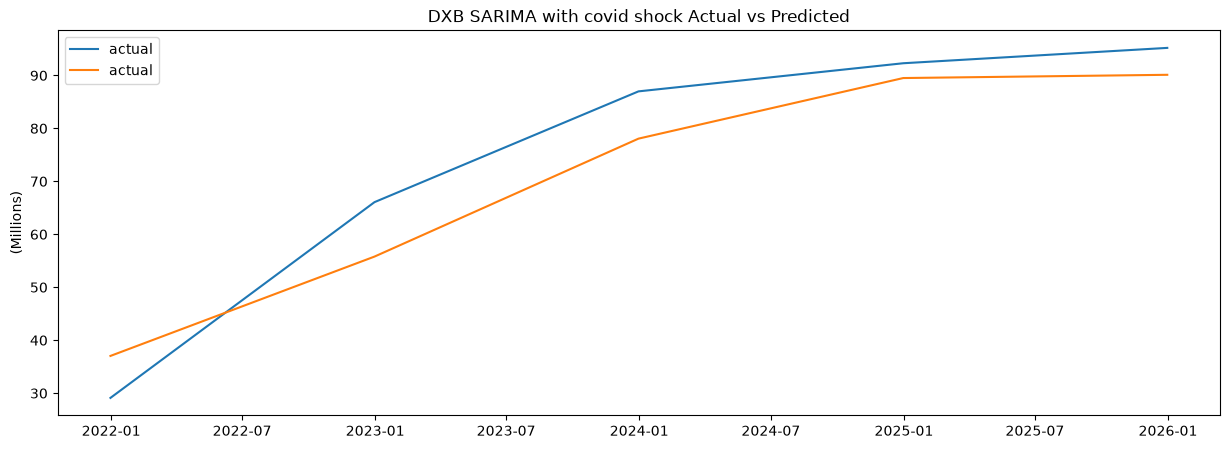

In [374]:
# lets plot actual vs predicted

plt.figure(figsize=(15, 5))

plt.plot(
    y_test.index,
    y_test/1_000_000,
    label="actual"
)



plt.plot(
    y_test.index,
    model_sarima_111_ce_forecast/1_000_000,
    label="actual"
)

plt.legend()
plt.title("DXB SARIMA with covid shock Actual vs Predicted")
plt.ylabel("(Millions)")
plt.show()

<Axes: xlabel='date'>

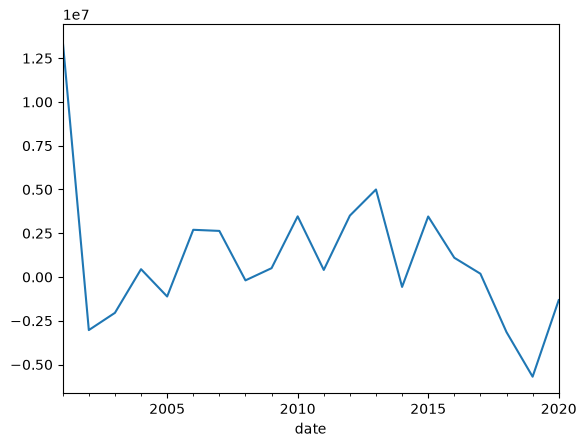

In [377]:
# lets plot resids

model_sarima_111_ce_traing.resid.plot()

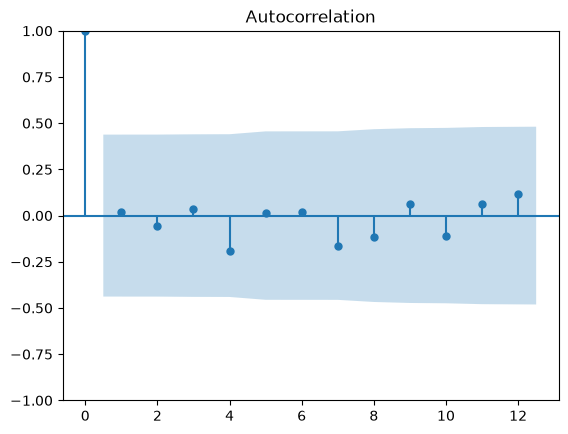

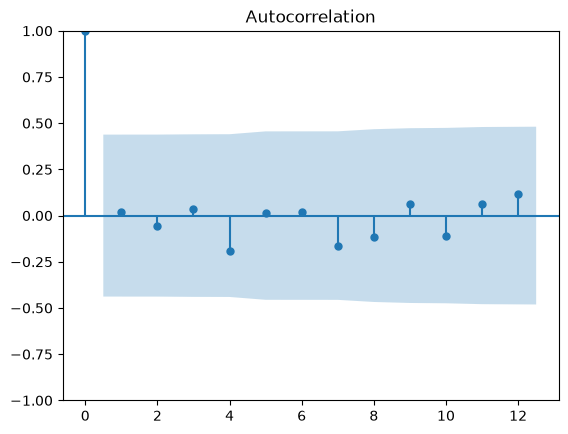

In [379]:
plot_acf(model_sarima_111_ce_traing.resid, lags=12)

In [ ]:
# resid looks normal no correlation with past lags

# so far our 3rd model seems best in terms of everything
# Model Sarima 111 (exog=Covid, Fuel)

# so we can do rolling test (like train 2001-2025 and test on 2020 (however we have covid shock in 2019 and 2020))
# so it will not be good idea to train non covid and test on covid

# hense we can choose this model for forecasting 2025-2030 and see the behaviour 

# so now we will train this model from 2001-2025 data and forecast for 2026-2030

In [411]:
# lets forecast 5 years dates range


# create date frame 2026 - 2030

f_date = pd.date_range(
                start="2026-12-31", 
                periods=5, 
                freq="YE"                
                )

f_date

DatetimeIndex(['2026-12-31', '2027-12-31', '2028-12-31', '2029-12-31',
               '2030-12-31'],
              dtype='datetime64[us]', freq='YE-DEC')

In [412]:
# now we will need exogenous variable value considering there will not be another covid shock and fuel price keeping estimate

# fuel price (we generate using simple MA 5years)

covid_shock = [0, 0, 0, 0, 0]

# df["avg_fuel_price_usd_l"].pct_change(5) * 100

# df["avg_fuel_price_usd_l"].rolling(5)

df["fp_ma_5"] = df["avg_fuel_price_usd_l"].rolling(5).mean()
df["fp_ma_3"] = df["avg_fuel_price_usd_l"].rolling(3).mean()

df[["avg_fuel_price_usd_l", "fp_ma_5", "fp_ma_3"]].tail(10)


,avg_fuel_price_usd_l,fp_ma_5,fp_ma_3
date,,,
2016-12-31,2.35000,2.83000,2.650000
2017-12-31,2.75000,2.77000,2.550000
2018-12-31,2.95000,2.73000,2.683333
2019-12-31,1.93875,2.50775,2.546250
2020-12-31,1.35000,2.26775,2.079583
2021-12-31,1.55000,2.10775,1.612917
2022-12-31,2.35000,2.02775,1.750000
2023-12-31,2.10000,1.85775,2.000000
2024-12-31,2.05000,1.88000,2.166667


so we will generate using rolling 3 (most closure this is just for this prototype as to identify real fuel price need to do lot deep research and depends on multiple factor such ecomnomy, global fuel price per barrel)

In [413]:
fp_ma_3 = df["fp_ma_3"].tail(5)

avg_fuel_price_usd_l = list(fp_ma_3)

In [420]:
# creating future assumption based exogenous variable
future_x_test = pd.DataFrame(
    {
        # "date" : f_date,
        "covid_effect" : covid_shock,
        "avg_fuel_price_usd_l" : avg_fuel_price_usd_l
        
    },index=f_date
)


future_x_test.sort_index(inplace=True)

# calling index as date
future_x_test.index.name = ("date")

future_x_test

,covid_effect,avg_fuel_price_usd_l
date,,
2026-12-31,0,1.612917
2027-12-31,0,1.750000
2028-12-31,0,2.000000
2029-12-31,0,2.166667
2030-12-31,0,2.066667


In [419]:
# creating final training data y_train_final, x_train_final


y_train_final = df.loc[:,"pax"]

# y_train_final.shape

# y_train_final.tail()


x_train_final = df.loc[:,['avg_fuel_price_usd_l', 'covid_effect']]
# x_train_final.tail()
x_train_final.shape

(25, 2)

In [421]:
# define model
model_final_sarima_111 = SARIMAX(
                                y_train_final,
                                exog=x_train_final,
                                order=(1, 1, 1)                                
                                )


# model training
model_final_sarima_111_training = model_final_sarima_111.fit()


# model summary
print(model_final_sarima_111_training.summary())

                               SARIMAX Results                                
Dep. Variable:                    pax   No. Observations:                   25
Model:               SARIMAX(1, 1, 1)   Log Likelihood                -402.987
Date:                Fri, 04 Sep 2026   AIC                            815.973
Time:                        21:31:52   BIC                            821.863
Sample:                    12-31-2001   HQIC                           817.536
                         - 12-31-2025                                         
Covariance Type:                  opg                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
avg_fuel_price_usd_l  7.093e+06   2.52e-08   2.81e+14      0.000    7.09e+06    7.09e+06
covid_effect          6.901e+07   6.37e-09   1.08e+16      0.000     6.9e+07     6.9e+07
ar.L1       

/Users/zara/Developer/Workspace/DS/Forecasting Models/venv_fm2/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency YE-DEC will be used.
  self._init_dates(dates, freq)
/Users/zara/Developer/Workspace/DS/Forecasting Models/venv_fm2/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency YE-DEC will be used.
  self._init_dates(dates, freq)
/Users/zara/Developer/Workspace/DS/Forecasting Models/venv_fm2/lib/python3.11/site-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/Users/zara/Developer/Workspace/DS/Forecasting Models/venv_fm2/lib/python3.11/site-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-invertible starting MA parameters found.

In [423]:
# now lets forecast using future_x_test (considering fuel price estimate of 3year ma and took 5 years data)
# this is just assemptions


forecast_pax_2026_2030 = model_final_sarima_111_training.forecast(len(future_x_test), exog=future_x_test)

forecast_pax_2026_2030/1_000_000

2026-12-31    194.591788
2027-12-31    206.663450
2028-12-31    226.517369
2029-12-31    240.609855
2030-12-31    236.288632
Freq: YE-DEC, Name: predicted_mean, dtype: float64

In [424]:
model_arima_final = ARIMA(
    y_train_final,
    order=(1, 1, 1)
)

model_arima_final_fit = model_arima_final.fit()

forecast_arima_final = model_arima_final_fit.forecast(steps=5)

forecast_arima_final / 1_000_000

/Users/zara/Developer/Workspace/DS/Forecasting Models/venv_fm2/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency YE-DEC will be used.
  self._init_dates(dates, freq)
/Users/zara/Developer/Workspace/DS/Forecasting Models/venv_fm2/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency YE-DEC will be used.
  self._init_dates(dates, freq)
/Users/zara/Developer/Workspace/DS/Forecasting Models/venv_fm2/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency YE-DEC will be used.
  self._init_dates(dates, freq)


2026-12-31    96.056407
2027-12-31    95.825923
2028-12-31    95.887953
2029-12-31    95.871259
2030-12-31    95.875752
Freq: YE-DEC, Name: predicted_mean, dtype: float64

In [425]:
print("ARIMA only:")
print(forecast_arima_final / 1_000_000)

print("\nSARIMAX + Fuel + COVID:")
print(forecast_pax_2026_2030 / 1_000_000)

ARIMA only:
2026-12-31    96.056407
2027-12-31    95.825923
2028-12-31    95.887953
2029-12-31    95.871259
2030-12-31    95.875752
Freq: YE-DEC, Name: predicted_mean, dtype: float64

SARIMAX + Fuel + COVID:
2026-12-31    194.591788
2027-12-31    206.663450
2028-12-31    226.517369
2029-12-31    240.609855
2030-12-31    236.288632
Freq: YE-DEC, Name: predicted_mean, dtype: float64


I initially included COVID as an intervention variable because it represented the structural disruption. During validation, I found that when the model was refitted on the full history, the estimated COVID coefficient caused an implausibly large long-term forecast. I therefore treated COVID as a temporary intervention rather than a continuing exogenous driver and evaluated a simpler baseline model.

In [428]:
# define model
model_final_sarima_011 = SARIMAX(
                                y_train_final,
                                exog=x_train_final,
                                order=(0, 1, 1)                                
                                )


# model training
model_final_sarima_011_training = model_final_sarima_011.fit()


# model summary
print(model_final_sarima_011_training.summary())


# forecasted value
model_final_sarima_011_forecast = model_final_sarima_011_training.forecast(len(x_test_fuel_ce), exog=x_test_fuel_ce)

model_final_sarima_011_forecast/1_000_000

                               SARIMAX Results                                
Dep. Variable:                    pax   No. Observations:                   25
Model:               SARIMAX(0, 1, 1)   Log Likelihood                -405.696
Date:                Fri, 04 Sep 2026   AIC                            819.392
Time:                        21:47:46   BIC                            824.105
Sample:                    12-31-2001   HQIC                           820.642
                         - 12-31-2025                                         
Covariance Type:                  opg                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
avg_fuel_price_usd_l  7.093e+06   3.38e+06      2.096      0.036    4.62e+05    1.37e+07
covid_effect          6.901e+07   6.17e+05    111.770      0.000    6.78e+07    7.02e+07
ma.L1       

/Users/zara/Developer/Workspace/DS/Forecasting Models/venv_fm2/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency YE-DEC will be used.
  self._init_dates(dates, freq)
/Users/zara/Developer/Workspace/DS/Forecasting Models/venv_fm2/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency YE-DEC will be used.
  self._init_dates(dates, freq)


2026-12-31    44.185397
2027-12-31    67.113291
2028-12-31    86.043731
2029-12-31    96.040957
2030-12-31    96.040957
Freq: YE-DEC, Name: predicted_mean, dtype: float64

In [429]:
x_final_fuel = df[["avg_fuel_price_usd_l"]]

model_011_fuel = SARIMAX(
    y_train_final,
    exog=x_final_fuel,
    order=(0, 1, 1)
)

model_011_fuel_fit = model_011_fuel.fit()

forecast_011_fuel = model_011_fuel_fit.forecast(
    steps=5,
    exog=future_x_test[["avg_fuel_price_usd_l"]]
)

forecast_011_fuel / 1_000_000

/Users/zara/Developer/Workspace/DS/Forecasting Models/venv_fm2/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency YE-DEC will be used.
  self._init_dates(dates, freq)
/Users/zara/Developer/Workspace/DS/Forecasting Models/venv_fm2/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency YE-DEC will be used.
  self._init_dates(dates, freq)


2026-12-31    85.996418
2027-12-31    88.787588
2028-12-31    93.877867
2029-12-31    97.271387
2030-12-31    95.235275
Freq: YE-DEC, Name: predicted_mean, dtype: float64

In [440]:
x_train_fuel = df.loc[ :"2020", "avg_fuel_price_usd_l"]
x_train_fuel.shape
y_train.shape

x_test_fuel = df.loc[ "2021":, "avg_fuel_price_usd_l"]
x_test_fuel

date
2021-12-31    1.55
2022-12-31    2.35
2023-12-31    2.10
2024-12-31    2.05
2025-12-31    2.05
Name: avg_fuel_price_usd_l, dtype: float64

In [441]:
# now lets test and train (2020 and test on 2025 and validate the model) SARIMA 011 

model_011_fuel = SARIMAX(
    y_train,
    exog=x_train_fuel,
    order=(0, 1, 1)
)

model_011_fuel_fit = model_011_fuel.fit()

forecast_011_fuel = model_011_fuel_fit.forecast(
    steps=5,
    exog=x_test_fuel
)

forecast_011_fuel / 1_000_000

/Users/zara/Developer/Workspace/DS/Forecasting Models/venv_fm2/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency YE-DEC will be used.
  self._init_dates(dates, freq)
/Users/zara/Developer/Workspace/DS/Forecasting Models/venv_fm2/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency YE-DEC will be used.
  self._init_dates(dates, freq)


2021-12-31    43.276080
2022-12-31    56.643472
2023-12-31    52.466162
2024-12-31    51.630700
2025-12-31    51.630700
Freq: YE-DEC, Name: predicted_mean, dtype: float64

In [443]:
model_accuracy("model_011_fuel", y_test, forecast_011_fuel)

Model : model_011_fuel 
 {'MAE': 28471008.993058823, 'MAPE': 0.3848934689294338, 'RMSE': 31729193.036737572}


#Final Findings

| Model                       | Backtest 2021–25 | Final 2026–30 | Problem                                  |
| --------------------------- | ---------------- | ------------- | ---------------------------------------- |
| ARIMA(1,1,1)                | Poor             | ~96M flat     | Doesn't handle COVID recovery well       |
| ARIMA(0,1,1) + Fuel         | Better backtest  | 86–97M        | Backtest setup is influenced by recovery |
| ARIMA(1,1,1) + Fuel + COVID | Better backtest  | 195–240M      | COVID coefficient explodes long-term     |
| ARIMA(0,1,1) + Fuel + COVID | —                | 44–96M        | Unstable recovery shape                  |


The model selection exercise showed me that COVID was a structural break rather than a normal observation. Some models performed well in backtesting but produced implausible long-term extrapolations when the recovery effect was allowed to continue. Therefore, for a strategic five-year airport forecast, I would use the statistical model as a baseline, separate the COVID recovery period from the underlying trend, incorporate relevant external drivers, and present base, upside and downside scenarios rather than relying on a single point forecast.